# Разработка модели для предсказания количества атомов по длине кривой
Необходимо разработать модель(алгоритм) для предсказания количества атомов на кривой и оценить точность данной модели

Гипотезы:
1. Алгоритмический подход. Расстояние между ca-атомами примерно 3.8. Поэтому следует рассмотреть подход разделение кривой на такие промежутки.

# Imports

In [1]:
import sys
import os
from typing import List, Tuple, Dict, Any
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math
import pandas as pd

# Добавляем корневую папку проекта в путь Python
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.utils.cfg import load_config
config = load_config()


КОНФИГУРАЦИЯ ПРОЕКТА
   Проект: vectoratomcurves
   Версия: 1.0.0
   Автор: Polyakov Stepan
   Датасет: data/dataset_10000_1_filtered
   Устройство: cuda



In [2]:
from tqdm import tqdm

In [3]:
cd ..

/home/stepan/VectorAtomCurves


In [4]:
import warnings
warnings.filterwarnings('ignore')
print("Предупреждения отключены")

Предупреждения отключены


# Загрузка данных 

In [5]:
from src.data.loader import load_and_preprocess_pdb_files
dataset_path = config.get('dataset', {}).get('path', 'N/A')
print(dataset_path)
pdb_files, ca_points = load_and_preprocess_pdb_files(dataset_path)

data/dataset_10000_1_filtered
Загрузка PDB файлов...


Обработка файлов: 0it [00:00, ?it/s]
Обработка файлов: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5390/5390 [00:36<00:00, 148.86it/s]


Загружено 5329 файлов, ошибок: 61


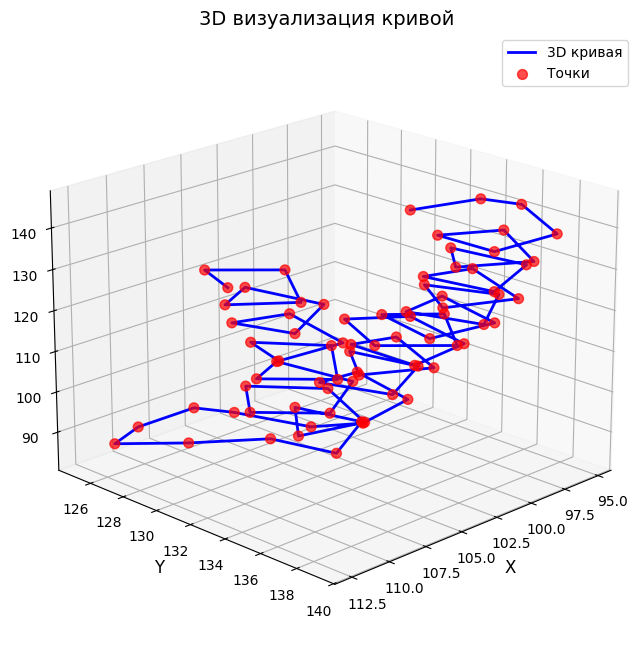

In [7]:
num_example = 0
points_array = np.array(ca_points[num_example])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = points_array[:, 0]
y = points_array[:, 1]
z = points_array[:, 2]

ax.plot(x, y, z, 'b-', linewidth=2, label='3D кривая')
ax.scatter(x, y, z, c='r', s=50, alpha=0.7, label='Точки')

# Настройки графика
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.set_title('3D визуализация кривой', fontsize=14)
ax.legend()
ax.grid(True)
ax.view_init(elev=20, azim=45)

plt.show()

Как можем видеть кривая не гладкая, ломанная для этого сделаем интерполяцию сплайнами, чтобы привести кривую к хорошему виду

# Интерполяция

In [8]:
from src.preprocessing.resample import resample_trajectories

In [9]:
k_points = 10000

In [10]:
no_intp_resampled_coords = resample_trajectories(ca_points, k_points, interpolate = False) #Оригинальные точки в новых координатах
intp_resampled_coords =  resample_trajectories(ca_points, k_points, interpolate = True) #Интерполированныее точки в новых координатах

Преобразование траекторий в инвариантные признаки (без интерполяции)...


Обработка: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [00:01<00:00, 4835.85it/s]


Ресемплирование траекторий до 10000 точек...


Обработка: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [07:10<00:00, 12.38it/s]


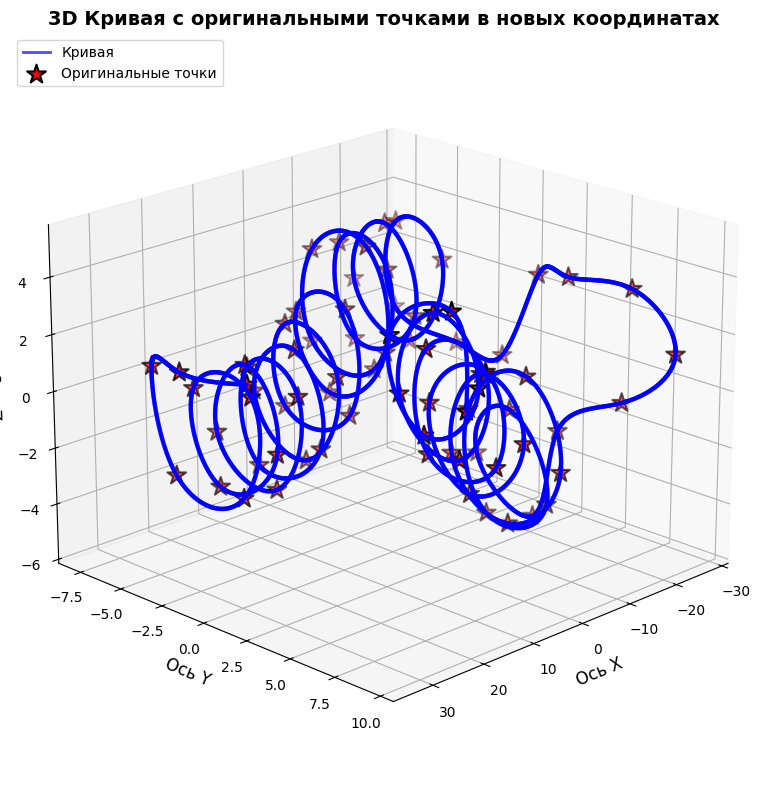

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

curves = intp_resampled_coords[num_example]
main_points = no_intp_resampled_coords[num_example]

# Создание 3D графика
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x_curve = curves[:, 0]
y_curve = curves[:, 1]
z_curve = curves[:, 2]

ax.plot(x_curve, y_curve, z_curve, 
        'b-', linewidth=2, alpha=0.7, label='Кривая')

ax.scatter(x_curve, y_curve, z_curve, 
          c='blue', s=20, alpha=0.5, marker='.')

x_main = main_points[:, 0]
y_main = main_points[:, 1]
z_main = main_points[:, 2]

ax.scatter(x_main, y_main, z_main, c = 'red',
          s=200, marker='*', edgecolors='black', linewidth=1.5,
          label='Оригинальные точки')

# Настройка графика
ax.set_xlabel('Ось X', fontsize=12)
ax.set_ylabel('Ось Y', fontsize=12)
ax.set_zlabel('Ось Z', fontsize=12)
ax.set_title('3D Кривая с оригинальными точками в новых координатах', fontsize=14, fontweight='bold')

# Легенда
ax.legend(loc='upper left', fontsize=10)

# Вращение для лучшего обзора
ax.view_init(elev=20, azim=45)

# Сетка
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Теперь кривая представлена в инвариантных координата и более гладкая перейдем к построению алгоритмической модели

# Примитив
Разделять кривую на равные промежутки, пока среднее расстояние между точками, не будет равно 3.8

In [14]:
import numpy as np

def uniform_sample_points(points, num_samples=10):
    points = np.array(points)
    indices = np.linspace(0, len(points) - 1, num_samples, dtype=int)
    sampled_points = points[indices]
    
    return sampled_points, indices

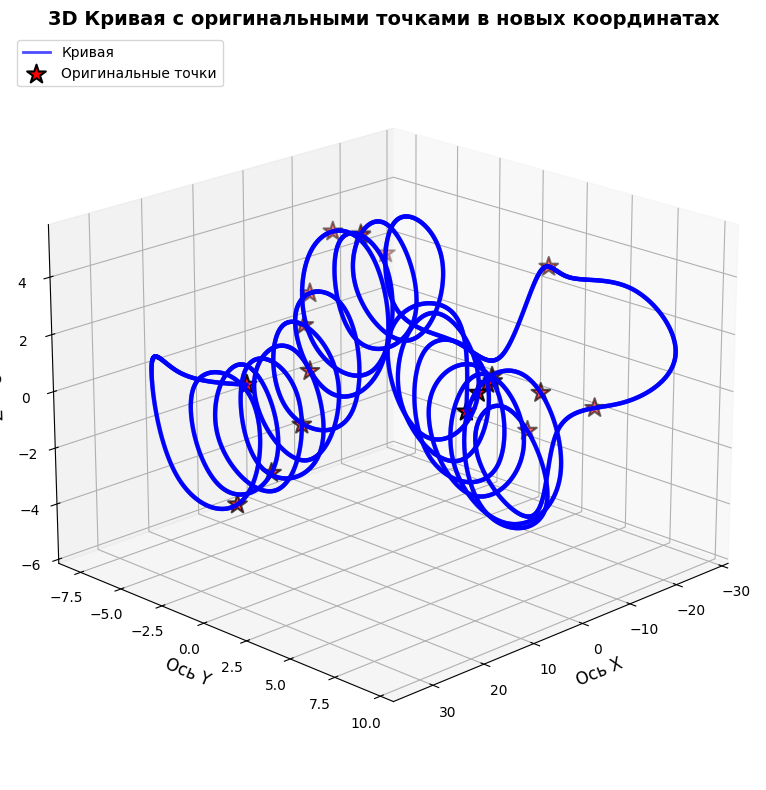

In [15]:
curves = intp_resampled_coords[num_example]
main_points = uniform_sample_points(curves, 20)[0]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x_curve = curves[:, 0]
y_curve = curves[:, 1]
z_curve = curves[:, 2]

ax.plot(x_curve, y_curve, z_curve, 
        'b-', linewidth=2, alpha=0.7, label='Кривая')

ax.scatter(x_curve, y_curve, z_curve, 
          c='blue', s=20, alpha=0.5, marker='.')

x_main = main_points[:, 0]
y_main = main_points[:, 1]
z_main = main_points[:, 2]

ax.scatter(x_main, y_main, z_main, c = 'red',
          s=200, marker='*', edgecolors='black', linewidth=1.5,
          label='Оригинальные точки')

ax.set_xlabel('Ось X', fontsize=12)
ax.set_ylabel('Ось Y', fontsize=12)
ax.set_zlabel('Ось Z', fontsize=12)
ax.set_title('3D Кривая с оригинальными точками в новых координатах', fontsize=14, fontweight='bold')

ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
#Функция расчета среднего расстояния между i, i+1 точкой
def average_distance_numpy(points):
    if len(points) < 2:
        return 0
    differences = np.diff(points, axis=0)
    distances = np.sqrt(np.sum(differences**2, axis=1))
    return np.mean(distances)

In [17]:
#Цикл перебора количества точек
threshold = 3.8

curves = intp_resampled_coords[num_example]
true_points = no_intp_resampled_coords[num_example]
print(f'Истинное количество точек: {len(true_points)}')

error = float(np.inf)
optimal_count = 0
for count in range(3, len(curves) // 2):
    main_points = uniform_sample_points(curves, count)[0]
    mean_dist = average_distance_numpy(main_points)

    if np.abs(threshold - mean_dist) < error:
        error = np.abs(threshold - mean_dist)
        optimal_count = count
    
print(f'Ошибка: {error}')
print(f'Найденное количество атомов: {optimal_count}')
print(f'Ошибка в количестве: {len(true_points) - optimal_count}')


Истинное количество точек: 76
Ошибка: 0.005602992215645308
Найденное количество атомов: 76
Ошибка в количестве: 0


Опишем все это в функцию
# Фукция для оценки количества атомов(равномерное)

Сделаем расчет ошибки на датасете

In [18]:
def find_true_atom(curves, threshold=3.8):
    error = float('inf')
    optimal_count = 0
    
    for count in range(3, len(curves)):
        main_points = uniform_sample_points(curves, count)[0]
        mean_dist = average_distance_numpy(main_points)
    
        current_error = np.abs(threshold - mean_dist)
        if current_error < error:
            error = current_error
            optimal_count = count
            
    return optimal_count, error

In [27]:
import multiprocessing
from multiprocessing import Pool
import numpy as np
from tqdm import tqdm

def process_example(args):
    example_idx, curve = args
    optimal_count, func_error = find_true_atom(curve)
    true_count = len(no_intp_resampled_coords[example_idx])
    count_error = np.abs(optimal_count - true_count)
    return example_idx, optimal_count, count_error

examples = list(enumerate(intp_resampled_coords))
num_processes = multiprocessing.cpu_count()
    
with Pool(processes=num_processes) as pool:
    results = list(tqdm(pool.imap(process_example, examples), 
                           total=len(examples)))
    
    results.sort(key=lambda x: x[0])
    
    optimal_counts = [r[1] for r in results]
    error_arr = [r[2] for r in results]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [03:14<00:00, 27.43it/s]


In [28]:
print(f'Максимальная ошибка:{np.array(error_arr).max()}')
print(f'Средняя ошибка: {np.array(error_arr).mean()}')
print(f'Минимальная ошибка: {np.array(error_arr).min()}')
print(f'Стандартное отклонение: {np.array(error_arr).std()}')

Максимальная ошибка:66
Средняя ошибка: 3.4451116532182398
Минимальная ошибка: 0
Стандартное отклонение: 3.547500769714007


# Иттеративное построение

In [34]:
import numpy as np
from typing import List, Tuple

def filter_points_by_distance(points: np.ndarray, target_distance: float = 3.8) -> np.ndarray:
    if len(points) == 0:
        return np.array([])
    
    selected_indices = [0]
    current_index = 0
    
    while current_index < len(points) - 1:
        remaining_points = points[current_index + 1:]
        
        distances = np.linalg.norm(remaining_points - points[current_index], axis=1)
        
        closest_idx = np.argmin(np.abs(distances - target_distance))
        
        next_index = current_index + 1 + closest_idx
        selected_indices.append(next_index)
        current_index = next_index
    
    return points[selected_indices]

error_arr = []
optimal_counts = []

for example in tqdm(range(len(intp_resampled_coords))):
    curve = intp_resampled_coords[example]
    optimal_count = len(filter_points_by_distance(curve)) 
    
    true_count = len(no_intp_resampled_coords[example])
    count_error = np.abs(optimal_count - true_count)  
    
    error_arr.append(count_error)
    optimal_counts.append(optimal_count)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [01:00<00:00, 88.48it/s]


In [35]:
print(f'Максимальная ошибка:{np.array(error_arr).max()}')
print(f'Средняя ошибка: {np.array(error_arr).mean()}')
print(f'Минимальная ошибка: {np.array(error_arr).min()}')
print(f'Стандартное отклонение: {np.array(error_arr).std()}')

Максимальная ошибка:476
Средняя ошибка: 27.829048601989115
Минимальная ошибка: 0
Стандартное отклонение: 49.136287928396925


# Машинное обучение
Попробуем предсказывать количество атомов с помощью линейной регрессии по длине
Для начала организуем датасет

In [12]:
intp = intp_resampled_coords
no_intp = no_intp_resampled_coords

In [13]:
def curve_length(points):
    if len(points) < 2:
        return 0
    
    length = 0
    for i in range(len(points) - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]
        length += math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    return length

In [14]:
intp[0]

array([[32.54329554,  1.17000949,  2.03430941],
       [32.55386769,  1.14086106,  2.02999464],
       [32.5644373 ,  1.11171293,  2.02568045],
       ...,
       [18.86604036,  9.35522381,  2.09642792],
       [18.88483629,  9.35886587,  2.06727517],
       [18.90363348,  9.36250571,  2.03811997]], shape=(10000, 3))

In [15]:
def curve_length_3d(points):
    if len(points) < 2:
        return 0.0
    
    total_length = 0.0
    for i in range(len(points) - 1):
        x1, y1, z1 = points[i]
        x2, y2, z2 = points[i + 1]
        
        dx = x2 - x1
        dy = y2 - y1
        dz = z2 - z1
        
        segment_length = math.sqrt(dx*dx + dy*dy + dz*dz)
        total_length += segment_length
    
    return total_length

In [16]:
len_curves_array = []

In [17]:
for sample in tqdm(intp):
    len_curves_array.append(curve_length_3d(sample))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [03:02<00:00, 29.19it/s]


In [18]:
atom_counts = []

In [19]:
for sample in tqdm(no_intp):
    atom_counts.append(len(sample))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [00:00<00:00, 2460258.23it/s]


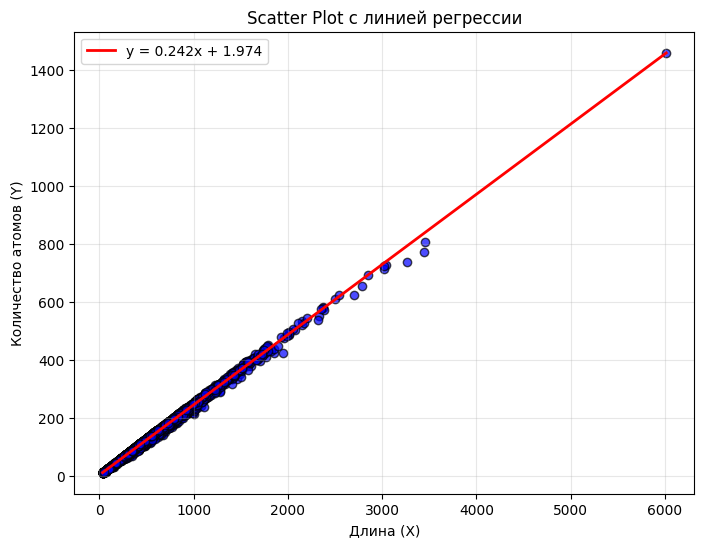

Уравнение прямой: y = 0.2425x + 1.9741
Коэффициент детерминации R² = 0.9975


In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
plt.scatter(len_curves_array, atom_counts, color='blue', alpha=0.7, edgecolors='black')


coefficients = np.polyfit(len_curves_array, atom_counts, 1)  
poly = np.poly1d(coefficients)

x_line = np.linspace(min(len_curves_array), max(len_curves_array), 100)
y_line = poly(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'y = {coefficients[0]:.3f}x + {coefficients[1]:.3f}')

plt.title('Scatter Plot с линией регрессии')
plt.xlabel('Длина (X)')
plt.ylabel('Количество атомов (Y)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Уравнение прямой: y = {coefficients[0]:.4f}x + {coefficients[1]:.4f}")

y_pred = poly(len_curves_array)
residuals = atom_counts - y_pred
ss_res = np.sum(residuals**2)
ss_tot = np.sum((atom_counts - np.mean(atom_counts))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"Коэффициент детерминации R² = {r_squared:.4f}")

In [21]:
from src.features.CurveAnalyser import MoleculeCurveAnalyzer

In [22]:
array_of_stats = [MoleculeCurveAnalyzer(intp[0]).get_characteristics_table()]

In [23]:
curve_length_3d(intp[0])

308.1969902884342

In [24]:
array_of_stats = []
for sample in tqdm(intp):
    array_of_stats.append(MoleculeCurveAnalyzer(sample).get_characteristics_table())
    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [00:09<00:00, 534.62it/s]


In [25]:
data_list = []
for stats in array_of_stats:
    data_dict = {metric: value for metric, value in stats}
    data_list.append(data_dict)

df = pd.DataFrame(data_list)

In [26]:
df['len'] = len_curves_array

In [27]:
df['target'] = atom_counts

In [28]:
df

,len,mean,median,std,variance,min,max,range,q25,q75,iqr,skewness,mean_gradient,max_gradient,min_gradient,std_gradient,total_variation,target
0,308.196990,-0.133070,-0.347686,9.942725,98.857772,-26.999874,33.187972,60.187847,-4.162974,3.621752,7.784726,0.712511,-0.000182,0.031754,-0.032057,0.017822,469.638340,76
1,600.781837,0.064355,1.024218,13.248238,175.515798,-36.893270,28.001778,64.895048,-5.167369,8.796565,13.963933,-2.270171,0.000442,0.067892,-0.081167,0.034920,899.986902,150
2,486.629158,-0.932158,-0.905400,10.172278,103.475234,-36.538029,24.850020,61.388049,-6.534162,4.829571,11.363733,-0.652360,-0.002205,0.057514,-0.065230,0.028273,728.942425,104
3,649.054790,-0.260541,-0.314623,9.541190,91.034316,-25.353204,25.041889,50.395093,-5.863211,6.064961,11.928173,-0.328656,-0.000286,0.078135,-0.076093,0.037697,970.285532,158
4,159.997005,0.077442,0.317674,8.355598,69.816010,-19.339905,21.604610,40.944515,-4.004101,4.857186,8.861288,0.197724,0.001385,0.016944,-0.016833,0.009163,243.634584,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,180.360155,0.007083,-0.341315,5.396377,29.120881,-12.862481,10.711981,23.574461,-3.931132,4.440614,8.371746,-0.617996,0.000161,0.019727,-0.019160,0.010441,271.065199,45
5325,560.143250,-0.099066,-0.461562,8.553259,73.158246,-18.877234,25.686595,44.563829,-5.967280,4.741666,10.708946,1.256205,0.000750,0.064908,-0.073549,0.032513,838.696800,136
5326,725.707136,-0.065171,0.357410,9.852688,97.075463,-25.599431,24.915825,50.515256,-7.367486,6.828988,14.196474,-0.130006,-0.000110,0.079599,-0.085853,0.042049,1099.603045,181
5327,343.432955,0.065279,0.106242,7.171329,51.427956,-25.389730,14.420881,39.810611,-4.874267,5.310725,10.184992,-1.346282,0.000164,0.036459,-0.036702,0.019888,517.190783,85


# Модель по линейной регрессии по длине

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['len','variance']]
y = df['target']               

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_test_pred = model.predict(X_test)


In [31]:
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

MAE: 2.7473


# Модель по линейной регрессии по всем признакам 

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(['target'], axis=1)
y = df['target']               

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_test_pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

MAE: 2.5004


In [34]:
# Оценим на всем датасете

In [35]:
y_test_pred = model.predict(X)
print(f"MAE: {mean_absolute_error(y_test_pred, y):.4f}")

MAE: 2.4764


In [36]:
error_arr = np.array(np.abs(y_test_pred - y)).astype(int)

In [37]:
print(f'Максимальная ошибка:{np.array(error_arr).max()}')
print(f'Средняя ошибка: {np.array(error_arr).mean()}')
print(f'Минимальная ошибка: {np.array(error_arr).min()}')
print(f'Стандартное отклонение: {np.array(error_arr).std()}')

Максимальная ошибка:36
Средняя ошибка: 2.007693751172828
Минимальная ошибка: 0
Стандартное отклонение: 2.7935361063568864


# Модель бустинга  по всем признакам 

In [39]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.9/432.9 kB 14.2 MB/s eta 0:00:00


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Предполагаем, что df уже определен
X = df.drop(['target'], axis=1)
y = df['target']

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

model = CatBoostRegressor(
    random_state=42
)

model.fit(X_train, y_train)

Learning rate set to 0.051484
0:	learn: 83.8254128	total: 50.8ms	remaining: 50.8s
1:	learn: 80.3058759	total: 53.9ms	remaining: 26.9s
2:	learn: 76.7007880	total: 55.9ms	remaining: 18.6s
3:	learn: 73.4658800	total: 57.6ms	remaining: 14.4s
4:	learn: 70.4255589	total: 59.5ms	remaining: 11.8s
5:	learn: 67.4222796	total: 61.3ms	remaining: 10.2s
6:	learn: 64.5735887	total: 63.2ms	remaining: 8.96s
7:	learn: 61.8769201	total: 65ms	remaining: 8.06s
8:	learn: 59.2902663	total: 66.9ms	remaining: 7.36s
9:	learn: 56.8055410	total: 69.1ms	remaining: 6.84s
10:	learn: 54.3672797	total: 72.7ms	remaining: 6.54s
11:	learn: 52.0790795	total: 76ms	remaining: 6.25s
12:	learn: 49.9435376	total: 79.3ms	remaining: 6.02s
13:	learn: 47.9358335	total: 82.7ms	remaining: 5.82s
14:	learn: 46.0906309	total: 84.9ms	remaining: 5.58s
15:	learn: 44.3627986	total: 89.3ms	remaining: 5.49s
16:	learn: 42.6307078	total: 92.3ms	remaining: 5.34s
17:	learn: 40.9498632	total: 94.5ms	remaining: 5.16s
18:	learn: 39.3368039	total: 9

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_test_pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

MAE: 2.6912


# На нейросетях

In [43]:
intp = intp_resampled_coords
no_intp = no_intp_resampled_coords

In [44]:
intp[0]

array([[32.54329554,  1.17000949,  2.03430941],
       [32.55386769,  1.14086106,  2.02999464],
       [32.5644373 ,  1.11171293,  2.02568045],
       ...,
       [18.86604036,  9.35522381,  2.09642792],
       [18.88483629,  9.35886587,  2.06727517],
       [18.90363348,  9.36250571,  2.03811997]], shape=(10000, 3))

In [45]:
len_curves_array = []
for sample in tqdm(intp):
    len_curves_array.append(curve_length_3d(sample))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [03:20<00:00, 26.54it/s]


In [70]:
atom_counts = []
for sample in tqdm(no_intp):
    atom_counts.append(len(sample))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [00:00<00:00, 2023121.47it/s]


In [46]:
from torch.utils.data import Dataset, DataLoader

In [71]:
class LengthData(Dataset):
    def __init__(self, curves_data, counts):
        self.curves_points = curves_data
        self.target = counts
    def __len__(self):
        return len(self.target)
    def __getitem__(self, idx):
        return torch.tensor(self.curves_points[idx]), torch.tensor(self.target[idx])

In [72]:
import torch
from torch.utils.data import random_split, DataLoader


In [73]:
def split_dataset(dataset, train_ratio=0.8, val_ratio=0.2, seed=42):    
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    dataset_size = len(dataset)
    train_size = int(train_ratio * dataset_size)
    val_size = dataset_size - train_size
    
    train_dataset, val_dataset = random_split(
        dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )
    
    return train_dataset, val_dataset

In [74]:
dataset = LengthData(intp, atom_counts)

In [75]:
train_dataset, val_dataset = split_dataset(
    dataset=dataset, 
    train_ratio=0.8,
    val_ratio=0.2,
    seed=42
)

In [76]:
batch_size = 8

In [77]:
train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

In [78]:
val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=True
    )

In [83]:
dataset[0]

(tensor([[32.5433,  1.1700,  2.0343],
         [32.5539,  1.1409,  2.0300],
         [32.5644,  1.1117,  2.0257],
         ...,
         [18.8660,  9.3552,  2.0964],
         [18.8848,  9.3589,  2.0673],
         [18.9036,  9.3625,  2.0381]], dtype=torch.float64),
 tensor(76))

In [163]:
import torch
import torch.nn as nn


class CurveAtomPredictor(nn.Module):
    def __init__(self, input_length=10000):
        super().__init__()
        
        # Всего два сверточных слоя
        self.conv1 = nn.Conv1d(3, 64, kernel_size=31, stride=8, padding=15)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(8)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=15, stride=4, padding=7)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.AdaptiveAvgPool1d(1)
        
        # Всего один полносвязный слой
        self.fc1 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc = nn.Linear(64, 1)

        
    def forward(self, x):
        # Изменяем размерность
        x = x.permute(0, 2, 1)
        
        # Сверточные слои
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = x.squeeze(-1)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc(x)

        return x

In [164]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CurveAtomPredictor().to(device)

In [165]:
criterion = nn.L1Loss()  
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [166]:
import torch.nn.functional as F


In [167]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_batches = 0
    
    for data, target in train_loader:
        data = data.to(device).float()
        target = target.to(device).float().view(-1, 1)  
        
        optimizer.zero_grad()
        
        outputs = model(data)
        loss = criterion(outputs, target)
        
        loss.backward()
        optimizer.step()
        
        # Считаем loss
        train_loss += loss.item()
        train_batches += 1
    
    avg_train_loss = train_loss / train_batches
    
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():  
        for data, target in val_loader:
            data = data.to(device).float()
            target = target.to(device).float().view(-1, 1)
            
            outputs = model(data)
            loss = criterion(outputs, target)
            
            val_loss += loss.item()
            val_batches += 1
    
    avg_val_loss = val_loss / val_batches
    
    print(f'Epoch {epoch+1:2d}/{num_epochs} | '
          f'Train Loss: {avg_train_loss:.6f} | '
          f'Val Loss: {avg_val_loss:.6f}')

print("Обучение завершено!")



Epoch  1/100 | Train Loss: 35.929229 | Val Loss: 29.550500
Epoch  2/100 | Train Loss: 26.929501 | Val Loss: 24.617447
Epoch  3/100 | Train Loss: 14.898433 | Val Loss: 8.286894
Epoch  4/100 | Train Loss: 8.693915 | Val Loss: 7.858459
Epoch  5/100 | Train Loss: 8.256399 | Val Loss: 8.141725
Epoch  6/100 | Train Loss: 8.085810 | Val Loss: 7.799085
Epoch  7/100 | Train Loss: 7.948561 | Val Loss: 7.659089
Epoch  8/100 | Train Loss: 7.880790 | Val Loss: 9.475522
Epoch  9/100 | Train Loss: 7.782890 | Val Loss: 7.340408
Epoch 10/100 | Train Loss: 7.440459 | Val Loss: 9.312427
Epoch 11/100 | Train Loss: 7.144637 | Val Loss: 6.880730
Epoch 12/100 | Train Loss: 6.795641 | Val Loss: 6.420537
Epoch 13/100 | Train Loss: 6.848452 | Val Loss: 6.230748
Epoch 14/100 | Train Loss: 6.646674 | Val Loss: 6.179214
Epoch 15/100 | Train Loss: 6.465751 | Val Loss: 6.046397
Epoch 16/100 | Train Loss: 6.113039 | Val Loss: 6.133675
Epoch 17/100 | Train Loss: 6.356542 | Val Loss: 6.535438
Epoch 18/100 | Train Loss:

Лучшей оказалась простая линейная регрессия для оценки количества атомов